Available columns: ['averageInteractionsPerCrossing', 'p_Rhad1', 'p_Rhad', 'p_f3', 'p_weta2', 'p_Rphi', 'p_Reta', 'p_Eratio', 'p_f1', 'p_TRTPID']

Energy-related columns: ['pX_core57cellsEnergyCorrection', 'pX_maxEcell_energy', 'pX_neflowisolcoreConeEnergyCorrection', 'pX_topoetconecoreConeEnergyCorrection', 'p_Truth_Energy']
Electron-related columns: ['p_Truth_isElectron']
Train R²: 0.9480
Validation R²: 0.8808
Train RMSE: 12843.8494
Validation RMSE: 19282.1461
Top 15 Features and Their Importance:
                                   feature  importance       std
21                     p_deltaPhiRescaled2    0.320136  0.014082
18                               p_sigmad0    0.290216  0.029142
115                                pX_e233    0.179332  0.003953
27                              p_ptcone40    0.066038  0.004577
25                              p_ptcone20    0.058532  0.003967
26                              p_ptcone30    0.046353  0.003205
48          pX_core57cellsEnergyCorrecti

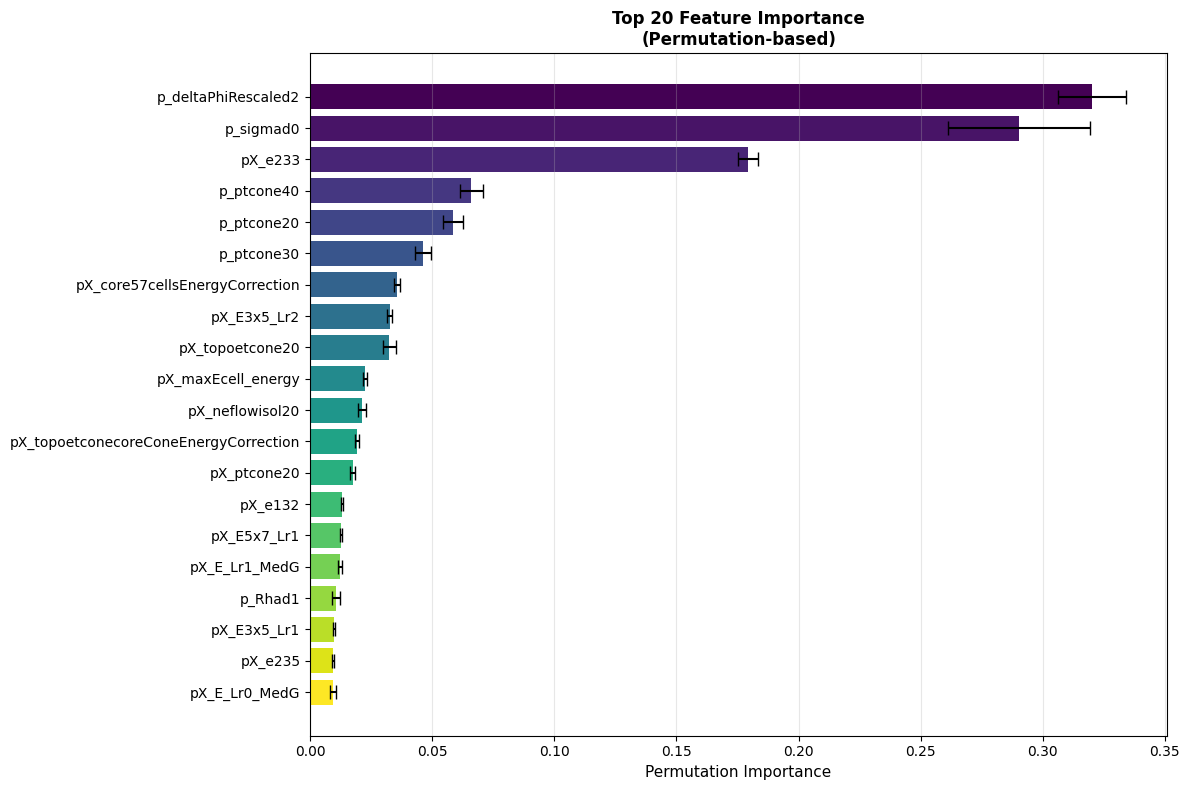

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader



# PyTorch MLP wrapped as sklearn-compatible regressor
class PyTorchNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, hidden_size=64, dropout=0.2, learning_rate=0.001, epochs=50, batch_size=32, random_state=42):
        self.hidden_size = hidden_size
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.model = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    def _build_model(self, input_dim):
        return nn.Sequential(
            nn.Linear(input_dim, self.hidden_size),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(self.hidden_size, self.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(self.hidden_size // 2, 1)
        ).to(self.device)
    
    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
        y_tensor = torch.FloatTensor(y.values if hasattr(y, 'values') else y).reshape(-1, 1).to(self.device)
        
        if self.model is None:
            self.model = self._build_model(X_tensor.shape[1])
        
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        criterion = nn.MSELoss()
        
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for _ in range(self.epochs):
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                output = self.model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                optimizer.step()
        
        return self
    
    def predict(self, X):
        X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
        self.model.eval()
        with torch.no_grad():
            predictions = self.model(X_tensor).cpu().numpy().flatten()
        return predictions
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = y.values if hasattr(y, 'values') else y
        return r2_score(y_true, y_pred)


# --- Data Loading and Initial Prep ---
reg_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')

# Check column names
print("Available columns:", reg_train_data.columns.tolist()[:10])
print("\nEnergy-related columns:", [col for col in reg_train_data.columns if 'energy' in col.lower()])
print("Electron-related columns:", [col for col in reg_train_data.columns if 'electron' in col.lower()])

# Filter for electrons only
electrons_mask = reg_train_data['p_Truth_isElectron'] == 1
reg_train_electrons = reg_train_data[electrons_mask].copy()

# Use the correct energy column name
energy_col = 'p_Truth_Energy' if 'p_Truth_Energy' in reg_train_electrons.columns else 'p_truth_Energy'
target = reg_train_electrons[energy_col]
variables = reg_train_electrons.drop(columns=['p_Truth_isElectron', energy_col])

reg_test_data = pd.read_csv('../Data/AppML_InitialProject_test_regression.csv')

# Normalize features
scaler = StandardScaler()
variables_scaled = pd.DataFrame(
    scaler.fit_transform(variables),
    columns=variables.columns,
    index=variables.index
)

# Split into train/validation for calculating importance on unseen data
X_train, X_val, y_train, y_val = train_test_split(
    variables_scaled, target, test_size=0.2, random_state=42
)

# Train PyTorch model
model = PyTorchNNRegressor(
    hidden_size=128,
    dropout=0.1,
    learning_rate=0.005,
    epochs=300,
    batch_size=32,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate on validation set
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
train_r2 = r2_score(y_train, train_pred)
val_r2 = r2_score(y_val, val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print(f'Train R²: {train_r2:.4f}')
print(f'Validation R²: {val_r2:.4f}')
print(f'Train RMSE: {train_rmse:.4f}')
print(f'Validation RMSE: {val_rmse:.4f}')

# Calculate permutation importance on validation set
perm_importance = permutation_importance(
    model, X_val, y_val,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

# Create results dataframe
importance_df = pd.DataFrame({
    'feature': variables.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Bar plot
top_n = 20
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=colors, capsize=5)
plt.xlabel('Permutation Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importance\n(Permutation-based)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

#Print top 15 features and their importance
print("Top 15 Features and Their Importance:")
print(importance_df.head(15))

In [19]:
print("Top 15 Features and Their Importance:")
print(importance_df.head(15))

Top 15 Features and Their Importance:
                                   feature  importance       std
21                     p_deltaPhiRescaled2    0.320136  0.014082
18                               p_sigmad0    0.290216  0.029142
115                                pX_e233    0.179332  0.003953
27                              p_ptcone40    0.066038  0.004577
25                              p_ptcone20    0.058532  0.003967
26                              p_ptcone30    0.046353  0.003205
48          pX_core57cellsEnergyCorrection    0.035501  0.001280
124                            pX_E3x5_Lr2    0.032606  0.001084
105                        pX_topoetcone20    0.032481  0.002651
73                      pX_maxEcell_energy    0.022546  0.000726
89                         pX_neflowisol20    0.021312  0.001502
111  pX_topoetconecoreConeEnergyCorrection    0.019303  0.000757
97                             pX_ptcone20    0.017416  0.001128
62                                 pX_e132    0.0129

In [20]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = PyTorchNNRegressor(
    hidden_size=128,
    dropout=0.1,
    learning_rate=0.005,
    epochs=300,
    batch_size=32,
    random_state=42
)

model_top.fit(X_train_top, y_train)
train_pred_top = model_top.predict(X_train_top)
val_pred_top = model_top.predict(X_val_top)
train_r2_top = r2_score(y_train, train_pred_top)
val_r2_top = r2_score(y_val, val_pred_top)

print(f'Train R² with top features: {train_r2_top:.4f}')
print(f'Validation R² with top features: {val_r2_top:.4f}')

Train R² with top features: 0.9241
Validation R² with top features: 0.8563


In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter tuning for PyTorch NN on the reduced 15-feature set
param_distributions = {
    'hidden_size': [64, 128, 256],
    'dropout': uniform(0.1, 0.4),
    'learning_rate': uniform(0.0001, 0.01),
    'epochs': randint(30, 100),
    'batch_size': [16, 32, 64]
}

random_search = RandomizedSearchCV(
    estimator=PyTorchNNRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_top, y_train)

print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_pred_tuned = best_model.predict(X_val_top)
val_r2_tuned = r2_score(y_val, val_pred_tuned)
val_rmse_tuned = np.sqrt(mean_squared_error(y_val, val_pred_tuned))
print(f'Validation R² after tuning: {val_r2_tuned:.4f}')
print(f'Validation RMSE after tuning: {val_rmse_tuned:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best CV score: 0.9044
Best parameters: {'batch_size': 32, 'dropout': np.float64(0.11016765069763808), 'epochs': 80, 'hidden_size': 256, 'learning_rate': np.float64(0.009057635956735194)}
Validation R² after tuning: 0.8933
Validation RMSE after tuning: 18246.0006


In [22]:
print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_pred_tuned = best_model.predict(X_val_top)
val_r2_tuned = r2_score(y_val, val_pred_tuned)
val_rmse_tuned = np.sqrt(mean_squared_error(y_val, val_pred_tuned))
print(f'Validation R² after tuning: {val_r2_tuned:.4f}')
print(f'Validation RMSE after tuning: {val_rmse_tuned:.4f}')

Best CV score: 0.9044
Best parameters: {'batch_size': 32, 'dropout': np.float64(0.11016765069763808), 'epochs': 80, 'hidden_size': 256, 'learning_rate': np.float64(0.009057635956735194)}
Validation R² after tuning: 0.8933
Validation RMSE after tuning: 18246.0006


In [23]:
# Compute relative MAE and total parameter count for PyTorch regressor
import numpy as np
from sklearn.metrics import mean_absolute_error

# Relative MAE: MAE of (P - T) / T (avoid divide-by-zero)
val_preds_reg = val_pred_tuned
y_val_arr = np.array(y_val if hasattr(y_val, 'values') else y_val).flatten()
# Avoid division by zero by using a small epsilon where true values are zero
eps = 1e-8
rel_dev = np.abs((val_preds_reg - y_val_arr) / np.maximum(y_val_arr, eps))
mae_relative_deviation = np.mean(rel_dev)

# Parameter count from PyTorch model wrapped in best_model
param_count = None
try:
    torch_model = best_model.model
    param_count = sum(p.numel() for p in torch_model.parameters() if p.requires_grad)
except Exception as e:
    print('Could not extract PyTorch model parameters:', e)

print(f'Relative MAE (validation): {mae_relative_deviation:.6f} ({mae_relative_deviation*100:.2f}%)')
print(f'Total trainable parameters (PyTorch regressor): {param_count:,}')

# Also print plain MAE for reference
try:
    mae_val = mean_absolute_error(y_val_arr, val_preds_reg)
    print(f'Validation MAE: {mae_val:.6f}')
except Exception:
    pass

Relative MAE (validation): 0.346493 (34.65%)
Total trainable parameters (PyTorch regressor): 38,401
Validation MAE: 8348.136638


In [24]:
from pathlib import Path

# Load test data, normalize with the training scaler, and extract top features
test_data_raw = pd.read_csv('../Data/AppML_InitialProject_test_regression.csv')
test_data_scaled = pd.DataFrame(
    scaler.transform(test_data_raw),
    columns=test_data_raw.columns
)

X_full_top = variables[top_feature_names]
best_model.fit(X_full_top, target)

X_test = test_data_scaled[top_feature_names]

# Get regression predictions for energy
test_predictions = best_model.predict(X_test)

# Define output paths and filenames
solution_name = "PyTorch"
name = "BenjaminSiddique"
output_dir = Path('../Regression/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Regression_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Regression_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")